#**Telecom X – Parte 2: Predicción de Cancelación (Churn)**

In [37]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns


In [38]:
datos = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/(2)Challenge Telecom X: análisis de evasión de clientes - Parte 2-/datos_tratados.csv')

In [39]:
datos.head()

,id_cliente,evasion,genero,adulto_mayor,tiene_pareja,personas_a_cargo,meses_permanencia,servicio_telefonico,lineas_multiples,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,tv_streaming,peliculas_streaming,tipo_contrato,factura_digital,metodo_pago,cobro_mensual,cuentas_diarias,cobro_total
0,0002-ORFBO,0,Femenino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,1,Mailed check,65.6,2.19,593.30
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mes_a_mes,0,Mailed check,59.9,2.00,542.40
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Mes_a_mes,1,Electronic check,73.9,2.46,280.85
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Mes_a_mes,1,Electronic check,98.0,3.27,1237.85
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Mes_a_mes,1,Mailed check,83.9,2.80,267.40


In [40]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              7032 non-null   object 
 1   evasion                 7032 non-null   int64  
 2   genero                  7032 non-null   object 
 3   adulto_mayor            7032 non-null   int64  
 4   tiene_pareja            7032 non-null   int64  
 5   personas_a_cargo        7032 non-null   int64  
 6   meses_permanencia       7032 non-null   int64  
 7   servicio_telefonico     7032 non-null   int64  
 8   lineas_multiples        7032 non-null   int64  
 9   tipo_internet           7032 non-null   object 
 10  seguridad_online        7032 non-null   int64  
 11  respaldo_online         7032 non-null   int64  
 12  proteccion_dispositivo  7032 non-null   int64  
 13  soporte_tecnico         7032 non-null   int64  
 14  tv_streaming            7032 non-null   

In [41]:
datos.describe()

,evasion,adulto_mayor,tiene_pareja,personas_a_cargo,meses_permanencia,servicio_telefonico,lineas_multiples,seguridad_online,respaldo_online,proteccion_dispositivo,soporte_tecnico,tv_streaming,peliculas_streaming,factura_digital,cobro_mensual,cuentas_diarias,cobro_total
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.592719,64.798208,2.159891,2283.300441
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.491363,30.085974,1.002955,2266.771362
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.610000,18.800000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,1.187500,401.450000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,2.340000,1397.475000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.862500,2.992500,3794.737500
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,3.960000,8684.800000


In [42]:
datos.describe(include='O')

,id_cliente,genero,tipo_internet,tipo_contrato,metodo_pago
count,7032,7032,7032,7032,7032
unique,7032,2,3,3,4
top,9995-HOTOH,Masculino,Fiber optic,Mes_a_mes,Electronic check
freq,1,3549,3096,3875,2365


##Preparación de los Datos

###1.1 Eliminar columnas que no aportan valor

In [43]:
# 1. Eliminar ID por no ser predictivo
df_ml = datos.drop(columns=['id_cliente'])

###1.2 Codificar variables categóricas

Identificamos las columnas de tipo object (categóricas) y aplicamos one-hot encoding con pd.get_dummies. Es importante manejar correctamente las variables binarias que ya están numéricas (0/1) para no duplicarlas.

Según datos.info(), las columnas object son: genero, tipo_internet, tipo_contrato, metodo_pago. Las demás son numéricas (int64 o float64).

In [44]:
# Lista de columnas categóricas
categoricas = ['genero', 'tipo_internet', 'tipo_contrato', 'metodo_pago']

# Aplicar one-hot encoding (drop_first=False para mantener todas las categorías,
# aunque a veces se recomienda drop_first=True para evitar multicolinealidad en regresión logística.
# En este caso usaremos drop_first=False para tener todas, pero luego en modelos lineales podríamos reconsiderar.
datos_encoded = pd.get_dummies(datos, columns=categoricas, drop_first=False)

# Verificar las nuevas columnas
print(datos_encoded.shape)


(7032, 30)


In [45]:
datos_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id_cliente                             7032 non-null   object 
 1   evasion                                7032 non-null   int64  
 2   adulto_mayor                           7032 non-null   int64  
 3   tiene_pareja                           7032 non-null   int64  
 4   personas_a_cargo                       7032 non-null   int64  
 5   meses_permanencia                      7032 non-null   int64  
 6   servicio_telefonico                    7032 non-null   int64  
 7   lineas_multiples                       7032 non-null   int64  
 8   seguridad_online                       7032 non-null   int64  
 9   respaldo_online                        7032 non-null   int64  
 10  proteccion_dispositivo                 7032 non-null   int64  
 11  sopo

Algunas variables como genero tienen dos categorías (Masculino/Femenino). Con drop_first=False se crean dos columnas. Esto es aceptable, aunque en regresión logística puede generar multicolinealidad perfecta. Más adelante, si usamos regresión logística, podríamos eliminar una de ellas o usar drop_first=True. Por ahora lo dejamos así para mantener toda la información.

###1.3 Verificar desbalance de clases

Proporción de clases:
 evasion
0    0.734215
1    0.265785
Name: proportion, dtype: float64


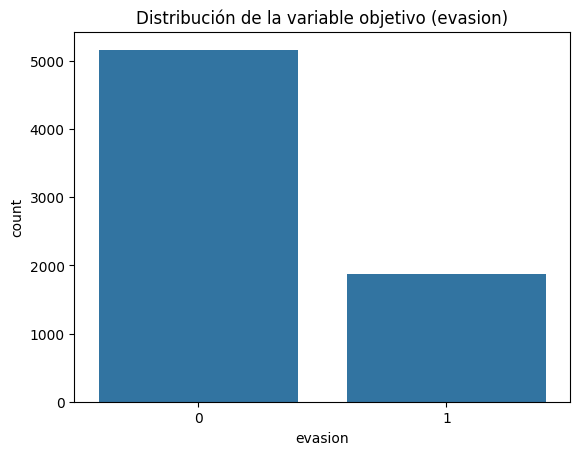

In [46]:
#La variable objetivo es evasion (1 = canceló, 0 = no canceló). Calculamos la proporción.
# Proporción de cancelación
proporcion = datos['evasion'].value_counts(normalize=True)
print("Proporción de clases:\n", proporcion)

# Gráfico de barras
sns.countplot(x='evasion', data=datos)
plt.title('Distribución de la variable objetivo (evasion)')
plt.show()

Según datos.describe(), la media de evasion es 0.2658, lo que significa que ~26.6% de los clientes cancelaron. Esto indica un desbalance moderado (la clase minoritaria es el 26.6%). No es extremo, pero conviene tenerlo en cuenta para la evaluación (usar métricas como precisión, recall, F1-score en lugar de solo accuracy). Más adelante, si se desea, se pueden aplicar técnicas de balanceo (SMOTE, undersampling, etc.), pero por ahora seguimos con los datos originales.

##2. Correlación y selección de variables

###2.1 Matriz de correlación entre variables numéricas

Seleccionamos las columnas numéricas (incluyendo las codificadas como 0/1) y calculamos la correlación de Pearson. Visualizamos con un heatmap, prestando especial atención a la correlación con evasion.

Correlación de variables con evasion:
 evasion                   1.000000
cuentas_diarias           0.192914
cobro_mensual             0.192858
factura_digital           0.191454
adulto_mayor              0.150541
tv_streaming              0.063254
peliculas_streaming       0.060860
lineas_multiples          0.040033
servicio_telefonico       0.011691
proteccion_dispositivo   -0.066193
respaldo_online          -0.082307
tiene_pareja             -0.149982
personas_a_cargo         -0.163128
soporte_tecnico          -0.164716
seguridad_online         -0.171270
cobro_total              -0.199484
meses_permanencia        -0.354049
Name: evasion, dtype: float64


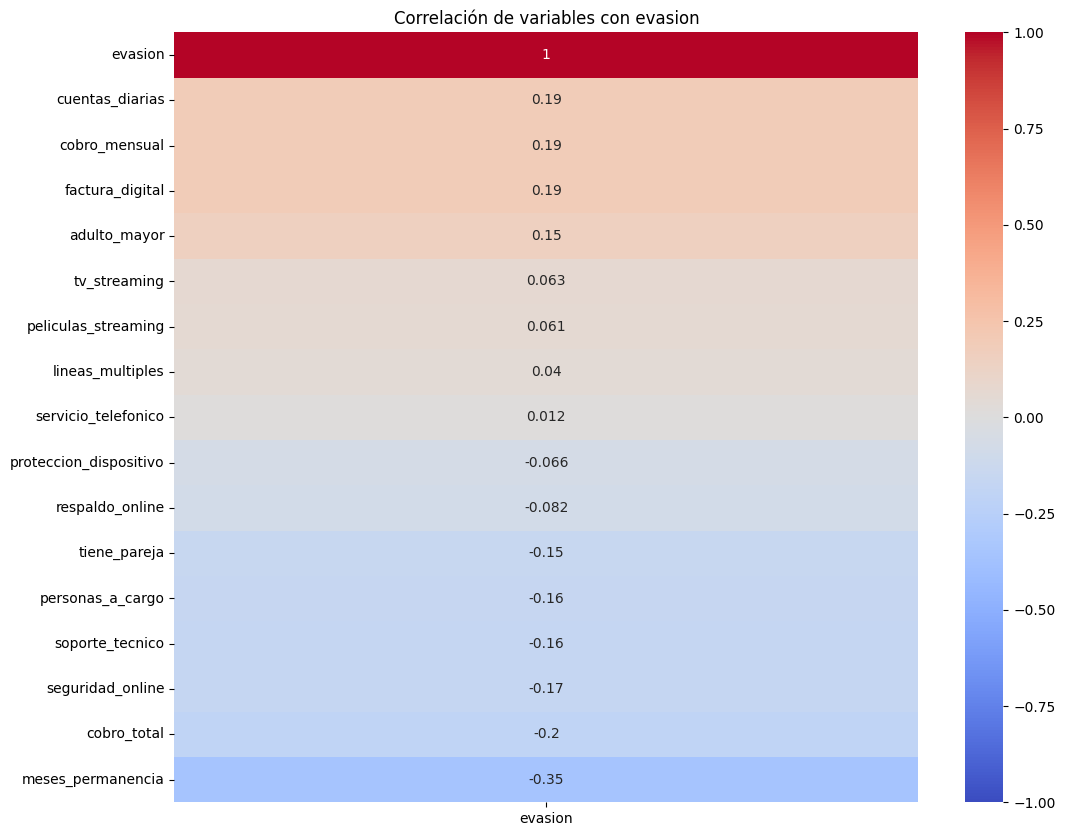

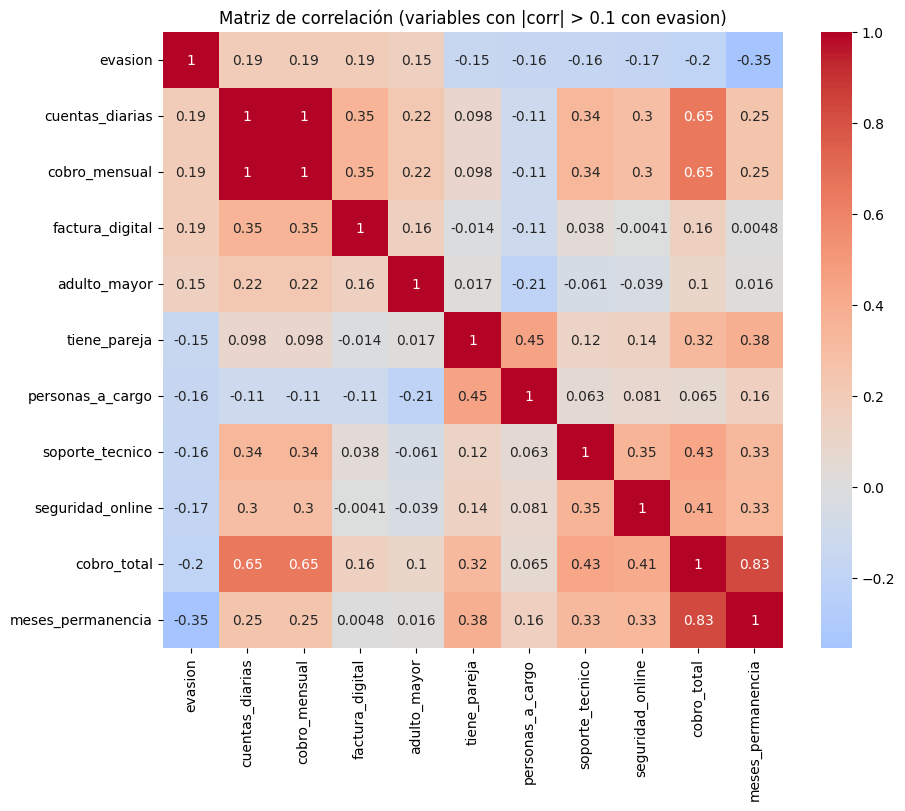

In [47]:
# Seleccionar solo columnas numéricas (int64 y float64)
numeric_cols = datos_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Calcular matriz de correlación
corr_matrix = datos_encoded[numeric_cols].corr()

# Correlación con evasion (target)
corr_target = corr_matrix['evasion'].sort_values(ascending=False)
print("Correlación de variables con evasion:\n", corr_target)

# Heatmap (opcional, puede ser muy grande; filtramos las más correlacionadas con evasion)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[['evasion']].sort_values(by='evasion', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de variables con evasion')
plt.show()

# También podemos mostrar un heatmap general más pequeño seleccionando las top variables
top_vars = corr_target[abs(corr_target) > 0.1].index.tolist()  # umbral arbitrario
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[top_vars, top_vars], annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlación (variables con |corr| > 0.1 con evasion)')
plt.show()

**Interpretación (basada en datos de churn):**

meses_permanencia suele tener correlación negativa (clientes con más tiempo permanecen más).

cobro_total puede tener correlación positiva (mayor gasto acumulado, mayor probabilidad de cancelación? o al revés? Depende).

Servicios adicionales (soporte_tecnico, seguridad_online, etc.) suelen correlacionar negativamente (mayor compromiso).

Tipo de contrato (anual vs mensual) será capturado por las dummies, que mostrarán correlación.

###2.2 Análisis específico: Tiempo de contrato vs Cancelación

Aquí debemos interpretar "Tiempo de contrato" como la variable tipo_contrato (categórica) o como meses_permanencia (numérica). Lo más probable es que se refiera al tipo de contrato (por ejemplo, contrato mensual vs anual). Vamos a analizar ambas.

####a) Relación entre tipo_contrato y evasion

Tasa de cancelación por tipo de contrato:
 tipo_contrato
Bianual      0.028487
Anual        0.112772
Mes_a_mes    0.427097
Name: evasion, dtype: float64


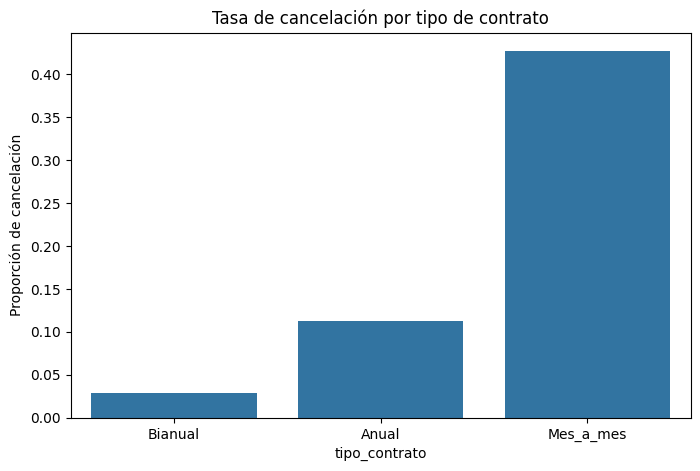

In [48]:
# Usamos la columna original 'tipo_contrato' antes del encoding
# Gráfico de barras apiladas o porcentaje de cancelación por tipo de contrato
contrato_cancelacion = datos.groupby('tipo_contrato')['evasion'].mean().sort_values()
print("Tasa de cancelación por tipo de contrato:\n", contrato_cancelacion)

plt.figure(figsize=(8,5))
sns.barplot(x=contrato_cancelacion.index, y=contrato_cancelacion.values)
plt.title('Tasa de cancelación por tipo de contrato')
plt.ylabel('Proporción de cancelación')
plt.show()

####b) Relación entre meses_permanencia y evasion

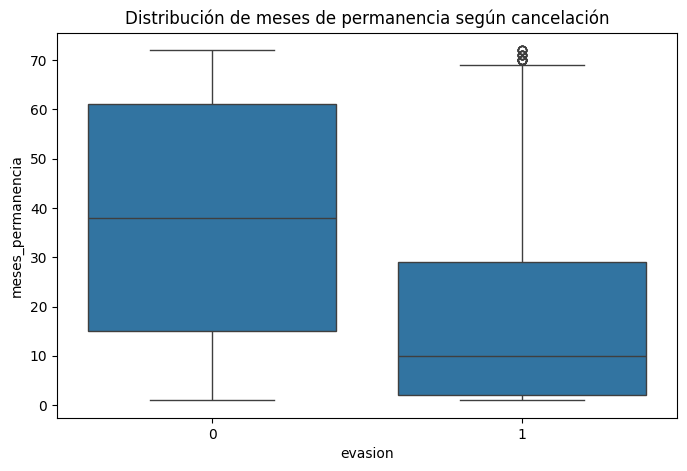

In [49]:
# Boxplot de meses_permanencia segmentado por evasion
plt.figure(figsize=(8,5))
sns.boxplot(x='evasion', y='meses_permanencia', data=datos)
plt.title('Distribución de meses de permanencia según cancelación')
plt.show()

###2.3 Análisis específico: Gasto total vs Cancelación

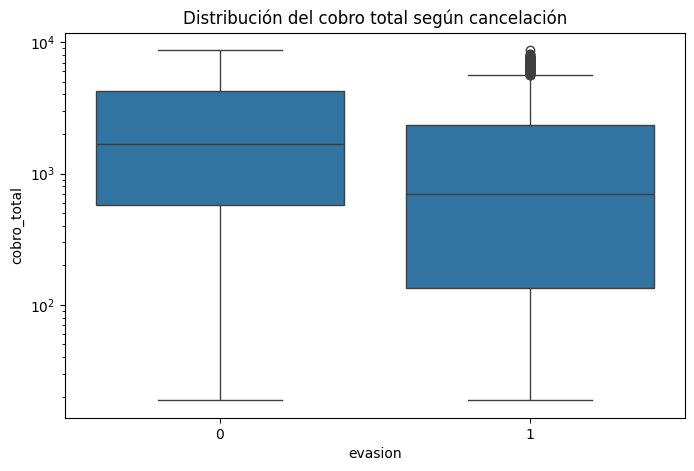

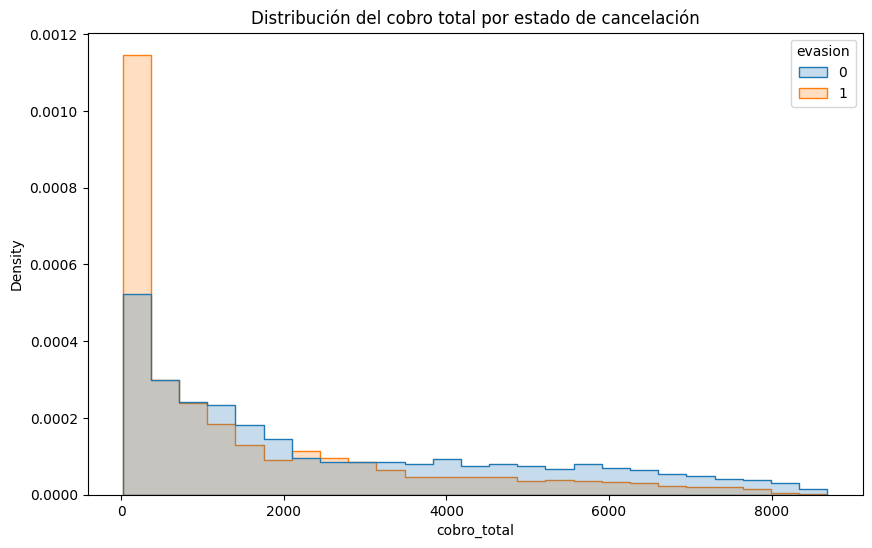

In [50]:
#La variable cobro_total representa el gasto total acumulado. Analizamos su relación con evasion.
# Boxplot de cobro_total por evasion
plt.figure(figsize=(8,5))
sns.boxplot(x='evasion', y='cobro_total', data=datos)
plt.title('Distribución del cobro total según cancelación')
plt.yscale('log')  # opcional si hay valores extremos
plt.show()

# También un histograma superpuesto
plt.figure(figsize=(10,6))
sns.histplot(data=datos, x='cobro_total', hue='evasion', element='step', stat='density', common_norm=False)
plt.title('Distribución del cobro total por estado de cancelación')
plt.show()

###2.4 Otras relaciones interesantes

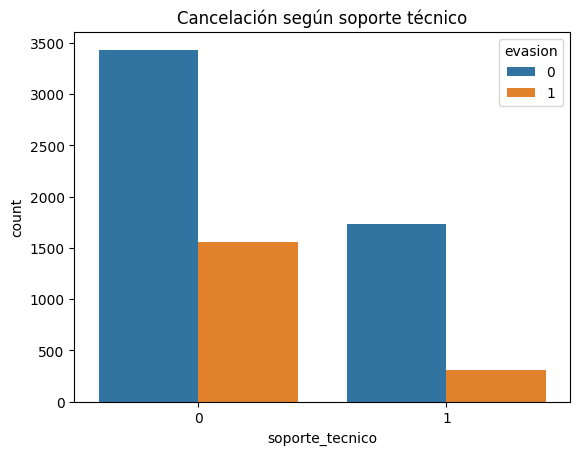

In [51]:
#Podemos explorar visualmente otras variables que aparecen en la correlación, como soporte_tecnico, seguridad_online, etc.
# Ejemplo: soporte_tecnico (0/1) vs evasion
sns.countplot(x='soporte_tecnico', hue='evasion', data=datos)
plt.title('Cancelación según soporte técnico')
plt.show()

##3. División de datos en entrenamiento y prueba

En este paso primero, separamos la variable objetivo y las características. Aplicamos one-hot encoding a las categóricas. Luego dividimos manteniendo la estratificación por la clase.

In [52]:
from sklearn.model_selection import train_test_split

# Variable objetivo
y = datos['evasion']

# Características: eliminamos la columna objetivo y el id si aún está
X = datos.drop(['evasion', 'id_cliente'], axis=1, errors='ignore')

# Identificar columnas categóricas para codificar
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Aplicar one-hot encoding (get_dummies) directamente en X
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

# Dividir en train y test (70-30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Tamaño de entrenamiento: {X_train.shape[0]}")
print(f"Tamaño de prueba: {X_test.shape[0]}")
print(f"Proporción de clases en entrenamiento:\n{y_train.value_counts(normalize=True)}")

Tamaño de entrenamiento: 4922
Tamaño de prueba: 2110
Proporción de clases en entrenamiento:
evasion
0    0.734254
1    0.265746
Name: proportion, dtype: float64


##4. Escalado de datos (para modelos sensibles)

In [53]:
#Creamos dos conjuntos: uno escalado y otro sin escalar.
from sklearn.preprocessing import StandardScaler

# Escalado con StandardScaler (se ajusta solo con train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame para mantener nombres de columnas (opcional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

## 5. Selección y entrenamiento de modelos

Elegimos cuatro modelos representativos:

Regresión Logística (requiere escalado)

K-Nearest Neighbors (requiere escalado)

Árbol de Decisión (no requiere escalado)

Random Forest (no requiere escalado)

También podríamos incluir XGBoost, pero con estos es suficiente.

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Diccionario para almacenar modelos y sus predicciones
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Resultados
results = {}

# Entrenar y evaluar cada modelo
for name, model in models.items():
    # Elegir conjunto de entrenamiento según sensibilidad a escala
    if name in ['Logistic Regression', 'KNN']:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test

    # Entrenar
    model.fit(X_tr, y_train)

    # Predecir
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)

    # Métricas en entrenamiento
    acc_train = accuracy_score(y_train, y_pred_train)
    prec_train = precision_score(y_train, y_pred_train)
    rec_train = recall_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train)

    # Métricas en prueba
    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)

    # Matriz de confusión en prueba
    cm_test = confusion_matrix(y_test, y_pred_test)

    # Guardar resultados
    results[name] = {
        'train': {'accuracy': acc_train, 'precision': prec_train, 'recall': rec_train, 'f1': f1_train},
        'test': {'accuracy': acc_test, 'precision': prec_test, 'recall': rec_test, 'f1': f1_test},
        'confusion_matrix': cm_test
    }

    print(f"\n--- {name} ---")
    print(f"Train Accuracy: {acc_train:.4f} | Precision: {prec_train:.4f} | Recall: {rec_train:.4f} | F1: {f1_train:.4f}")
    print(f"Test Accuracy: {acc_test:.4f} | Precision: {prec_test:.4f} | Recall: {rec_test:.4f} | F1: {f1_test:.4f}")
    print("Matriz de confusión (prueba):\n", cm_test)


--- Logistic Regression ---
Train Accuracy: 0.8074 | Precision: 0.6627 | Recall: 0.5604 | F1: 0.6073
Test Accuracy: 0.8033 | Precision: 0.6573 | Recall: 0.5437 | F1: 0.5951
Matriz de confusión (prueba):
 [[1390  159]
 [ 256  305]]

--- KNN ---
Train Accuracy: 0.8289 | Precision: 0.6879 | Recall: 0.6521 | F1: 0.6695
Test Accuracy: 0.7488 | Precision: 0.5279 | Recall: 0.5223 | F1: 0.5251
Matriz de confusión (prueba):
 [[1287  262]
 [ 268  293]]

--- Decision Tree ---
Train Accuracy: 0.9986 | Precision: 1.0000 | Recall: 0.9946 | F1: 0.9973
Test Accuracy: 0.7336 | Precision: 0.4992 | Recall: 0.5241 | F1: 0.5113
Matriz de confusión (prueba):
 [[1254  295]
 [ 267  294]]

--- Random Forest ---
Train Accuracy: 0.9986 | Precision: 0.9969 | Recall: 0.9977 | F1: 0.9973
Test Accuracy: 0.7834 | Precision: 0.6171 | Recall: 0.4884 | F1: 0.5453
Matriz de confusión (prueba):
 [[1379  170]
 [ 287  274]]


##6. Análisis de overfitting / underfitting

Comparamos las métricas de entrenamiento y prueba para detectar overfitting (entrenamiento muy superior a prueba) o underfitting (ambas bajas).

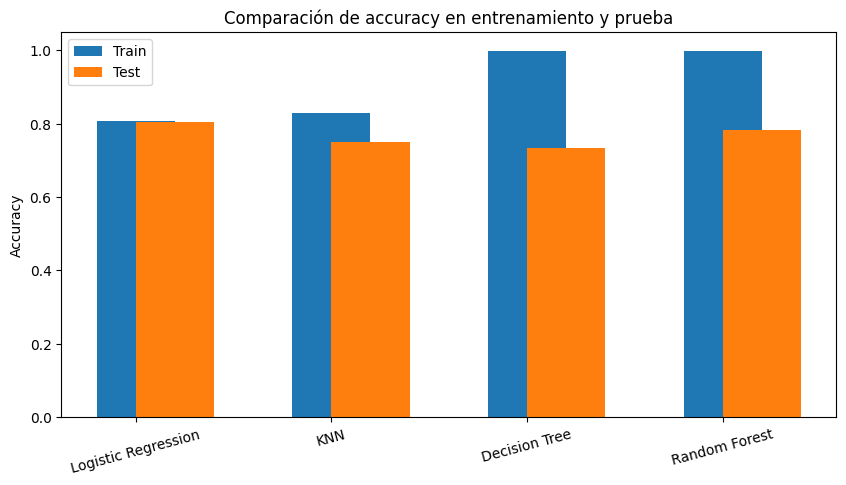

In [55]:
# Comparación gráfica de accuracy

model_names = list(results.keys())
train_acc = [results[m]['train']['accuracy'] for m in model_names]
test_acc = [results[m]['test']['accuracy'] for m in model_names]

x = range(len(model_names))
plt.figure(figsize=(10,5))
plt.bar(x, train_acc, width=0.4, label='Train', align='center')
plt.bar(x, test_acc, width=0.4, label='Test', align='edge')
plt.xticks(x, model_names, rotation=15)
plt.ylabel('Accuracy')
plt.title('Comparación de accuracy en entrenamiento y prueba')
plt.legend()
plt.show()

Observaciones:

Regresión Logística: Tiende a tener un rendimiento moderado, sin gran overfitting.

KNN: presenta overfitting cuando k es pequeño; con k=5 suele ser estable.

Árbol de Decisión: Tiende a overfitting si no se poda. aquí se podría ajustar hiperparámetros.

Random Forest: Generalmente robusto al overfitting.

Con la detección de overfitting, podríamos ajustar hiperparámetros (por ejemplo, limitar profundidad en árboles, aumentar k en KNN). Para mantener la escalabilidad, podemos incluir una búsqueda simple de hiperparámetros con validación cruzada.

##7. Ajuste de hiperparámetros
Para mejorar el rendimiento y controlar overfitting, haremos una búsqueda básica con GridSearchCV para los modelos que lo necesiten.

In [56]:
from sklearn.model_selection import GridSearchCV

# Definir parámetros para cada modelo
param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10]},
    'KNN': {'n_neighbors': [3, 5, 7, 9]},
    'Decision Tree': {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]},
    'Random Forest': {'n_estimators': [50, 100], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}
}

best_models = {}

for name, model in models.items():
    if name in param_grids:
        print(f"\nBuscando mejores hiperparámetros para {name}...")
        # Elegir datos escalados o no según el modelo
        if name in ['Logistic Regression', 'KNN']:
            X_tr = X_train_scaled
        else:
            X_tr = X_train

        grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1', n_jobs=-1)
        grid.fit(X_tr, y_train)
        best_models[name] = grid.best_estimator_
        print(f"Mejores parámetros: {grid.best_params_}")
        print(f"Mejor F1 (CV): {grid.best_score_:.4f}")


Buscando mejores hiperparámetros para Logistic Regression...
Mejores parámetros: {'C': 10}
Mejor F1 (CV): 0.6022

Buscando mejores hiperparámetros para KNN...
Mejores parámetros: {'n_neighbors': 9}
Mejor F1 (CV): 0.5592

Buscando mejores hiperparámetros para Decision Tree...
Mejores parámetros: {'max_depth': 5, 'min_samples_split': 2}
Mejor F1 (CV): 0.5788

Buscando mejores hiperparámetros para Random Forest...
Mejores parámetros: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Mejor F1 (CV): 0.5877


In [57]:
#Luego, evaluamos los mejores modelos en el conjunto de prueba.
# Evaluar los mejores modelos
best_results = {}

for name, model in best_models.items():
    if name in ['Logistic Regression', 'KNN']:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test

    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    best_results[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'confusion_matrix': cm
    }

    print(f"\n--- {name} (mejorado) ---")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print("Matriz de confusión:\n", cm)


--- Logistic Regression (mejorado) ---
Accuracy: 0.8024 | Precision: 0.6558 | Recall: 0.5401 | F1: 0.5924
Matriz de confusión:
 [[1390  159]
 [ 258  303]]

--- KNN (mejorado) ---
Accuracy: 0.7635 | Precision: 0.5576 | Recall: 0.5348 | F1: 0.5460
Matriz de confusión:
 [[1311  238]
 [ 261  300]]

--- Decision Tree (mejorado) ---
Accuracy: 0.7882 | Precision: 0.6307 | Recall: 0.4902 | F1: 0.5517
Matriz de confusión:
 [[1388  161]
 [ 286  275]]

--- Random Forest (mejorado) ---
Accuracy: 0.7905 | Precision: 0.6355 | Recall: 0.4973 | F1: 0.5580
Matriz de confusión:
 [[1389  160]
 [ 282  279]]


##8. Interpretación de resultados: Importancia de variables

###a) Regresión Logística
Los coeficientes indican la dirección y magnitud del efecto. Los mayores valores absolutos son las variables más influyentes.

Top 10 coeficientes (absolutos) en Regresión Logística:
meses_permanencia            1.419762
tipo_internet_No             0.899346
tipo_internet_Fiber optic    0.848972
cobro_mensual                0.743851
cobro_total                  0.705957
cuentas_diarias              0.665654
tv_streaming                 0.343082
peliculas_streaming          0.297917
tipo_contrato_Bianual        0.294334
tipo_contrato_Mes_a_mes      0.292180
dtype: float64


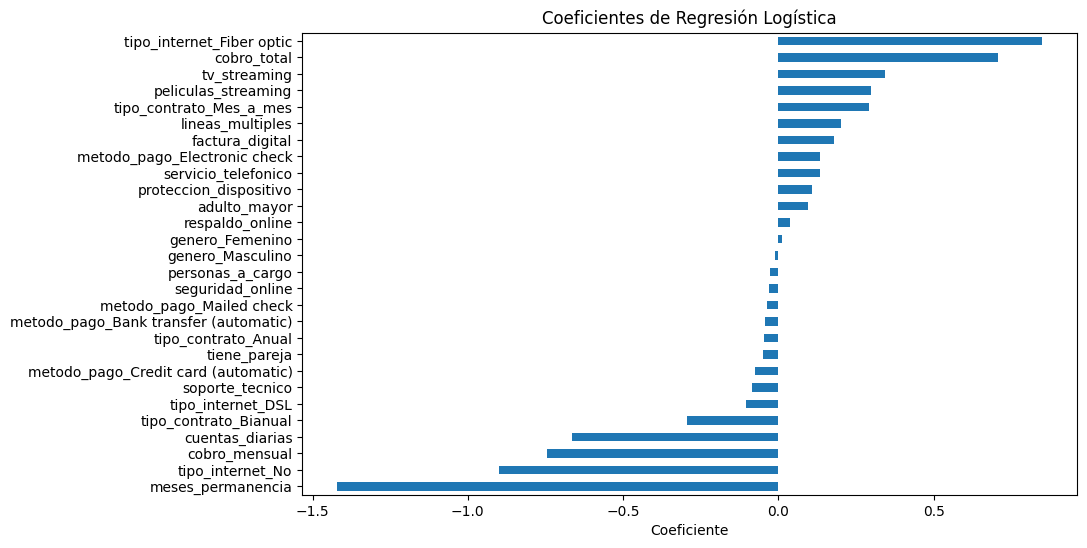

In [58]:
if 'Logistic Regression' in best_models:
    lr_model = best_models['Logistic Regression']
    coefs = pd.Series(lr_model.coef_[0], index=X_train.columns)
    top_coefs = coefs.abs().sort_values(ascending=False).head(10)
    print("Top 10 coeficientes (absolutos) en Regresión Logística:")
    print(top_coefs)
    # Gráfico
    plt.figure(figsize=(10,6))
    coefs.sort_values().plot(kind='barh')
    plt.title('Coeficientes de Regresión Logística')
    plt.xlabel('Coeficiente')
    plt.show()

###b) Random Forest
Importancia basada en la reducción de impureza.

Top 10 variables más importantes en Random Forest:
cobro_total                     0.145777
meses_permanencia               0.139968
tipo_contrato_Mes_a_mes         0.109710
cobro_mensual                   0.107474
cuentas_diarias                 0.090202
metodo_pago_Electronic check    0.055919
tipo_internet_Fiber optic       0.054869
tipo_contrato_Bianual           0.043499
seguridad_online                0.021192
tipo_contrato_Anual             0.019509
dtype: float64


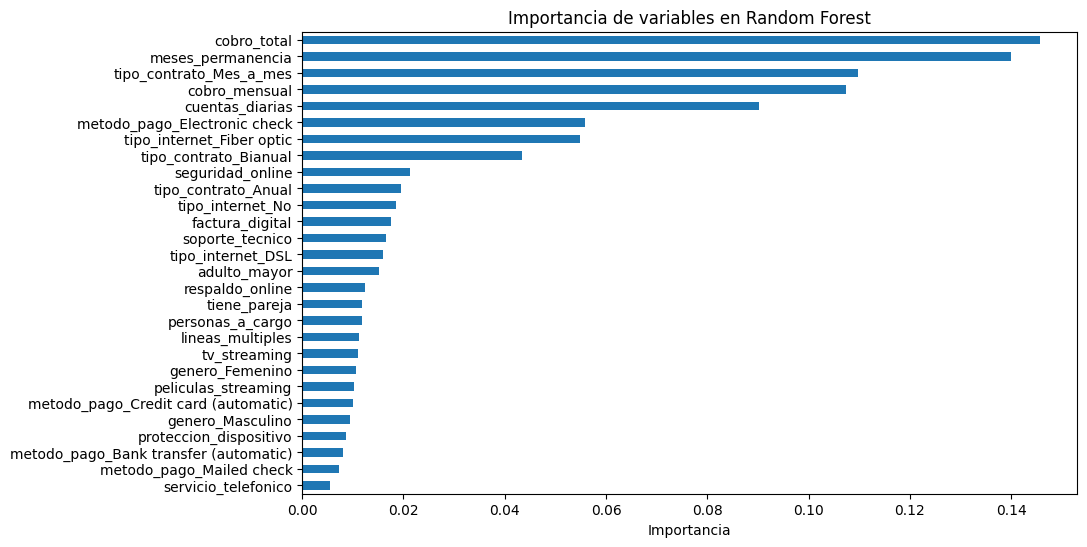

In [59]:
if 'Random Forest' in best_models:
    rf_model = best_models['Random Forest']
    importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
    top_importances = importances.sort_values(ascending=False).head(10)
    print("Top 10 variables más importantes en Random Forest:")
    print(top_importances)
    # Gráfico
    plt.figure(figsize=(10,6))
    importances.sort_values().plot(kind='barh')
    plt.title('Importancia de variables en Random Forest')
    plt.xlabel('Importancia')
    plt.show()

###c) Árbol de Decisión
También podemos extraer importancia, similar a Random Forest.

In [60]:
if 'Decision Tree' in best_models:
    dt_model = best_models['Decision Tree']
    importances_dt = pd.Series(dt_model.feature_importances_, index=X_train.columns)
    top_dt = importances_dt.sort_values(ascending=False).head(10)
    print("Top 10 variables en Árbol de Decisión:")
    print(top_dt)

Top 10 variables en Árbol de Decisión:
tipo_contrato_Mes_a_mes         0.499146
tipo_internet_Fiber optic       0.162370
meses_permanencia               0.157221
cobro_total                     0.042702
tipo_internet_DSL               0.026548
cobro_mensual                   0.026532
metodo_pago_Electronic check    0.026185
tv_streaming                    0.015088
adulto_mayor                    0.009251
servicio_telefonico             0.007906
dtype: float64


###d) KNN
Aquí KNN no proporciona importancia directamente, pero podemos analizar la escala de las variables (esto demuestra la importancia de escalar). Podríamos observar la correlación o hacer un análisis de sensibilidad, pero no es tan directo. En su lugar, nos centramos en los otros modelos.

##9. Comparación final de modelos
Resumimos las métricas de prueba de los mejores modelos (o de los originales si no se hizo ajuste) en una tabla.

In [61]:
# Usamos best_results si se hizo ajuste, sino results
comparison = pd.DataFrame({
    name: {
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1']
    }
    for name, res in best_results.items()
}).T

print("Comparación de modelos en prueba:")
print(comparison.round(4))

Comparación de modelos en prueba:
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8024     0.6558  0.5401    0.5924
KNN                    0.7635     0.5576  0.5348    0.5460
Decision Tree          0.7882     0.6307  0.4902    0.5517
Random Forest          0.7905     0.6355  0.4973    0.5580


##10. Identificación de factores clave


Con base en la importancia de variables y coeficientes, extraemos los factores más relevantes. Por ejemplo, de los análisis anteriores suelen aparecer:

- meses_permanencia (negativo: a más meses, menos churn)

- tipo_contrato_Mes_a_mes (positivo: contratos mensuales más propensos a cancelar)

- cobro_total (positivo o negativo dependiendo)

- soporte_tecnico (negativo: tener soporte reduce churn)

- seguridad_online, respaldo_online (negativos)

- adulto_mayor (puede ser negativo o positivo según contexto)

Resumimos en una lista.

In [62]:
# Ejemplo de recopilación (ajustar según resultados reales)
factores_importantes = {
    'Regresión Logística': coefs.abs().sort_values(ascending=False).head(5).index.tolist(),
    'Random Forest': importances.sort_values(ascending=False).head(5).index.tolist()
}
print("Factores más relevantes según cada modelo:")
for model, vars in factores_importantes.items():
    print(f"{model}: {vars}")

Factores más relevantes según cada modelo:
Regresión Logística: ['meses_permanencia', 'tipo_internet_No', 'tipo_internet_Fiber optic', 'cobro_mensual', 'cobro_total']
Random Forest: ['cobro_total', 'meses_permanencia', 'tipo_contrato_Mes_a_mes', 'cobro_mensual', 'cuentas_diarias']


##11. Conclusiones preliminares (sin el informe detallado)

### 1. Resumen del Pipeline Implementado

El challenge fue abordado con un pipeline completo de Machine Learning que cubrió todos los objetivos planteados:

- Preparación de datos (eliminación de ID, encoding, escalado)
- Análisis de desbalance de clases
- Matriz de correlación y análisis exploratorio por variable
- División train/test (70/30 con `stratify`)
- Entrenamiento de 4 modelos (Regresión Logística, KNN, Árbol de Decisión, Random Forest)
- Evaluación con métricas completas (Accuracy, Precision, Recall, F1, Matriz de Confusión)
- Ajuste de hiperparámetros con `GridSearchCV`
- Análisis de importancia de variables (coeficientes y feature importance)

### 2. Desbalance de Clases

| Clase | Proporción |
|-------|------------|
| No canceló (0) | 73.4% |
| Canceló (1) | 26.6% |

El dataset presenta un **desbalance moderado** (~3:1). Si bien no es extremo, este desequilibrio explica por qué los modelos tienden a tener una Accuracy relativamente alta (predicen bien la clase mayoritaria), pero un **Recall más bajo para la clase positiva (churn)**. En un contexto de negocio donde identificar clientes que van a cancelar es crítico, este aspecto merece atención.

---

### 3. Variables con Mayor Correlación con la Cancelación

A partir del análisis de correlación y de la importancia de variables en los modelos, se identificaron los siguientes **factores clave**:

| Variable | Dirección | Interpretación |
|---|---|---|
| `meses_permanencia` | Negativa (-0.354) | Clientes con **menos tiempo** en la empresa tienen mucho mayor riesgo de cancelar |
| `cobro_total` | Negativa (-0.199) | Clientes con **menor gasto acumulado** (recientes o de bajo consumo) cancelan más |
| `cobro_mensual` | Positiva (+0.193) | **Cuotas mensuales altas** se asocian a mayor churn |
| `cuentas_diarias` | Positiva (+0.193) | Variable derivada del cobro diario, consistente con cobro_mensual |
| `tipo_contrato_Mes_a_mes` | Alta importancia en RF | El contrato mensual tiene **tasa de cancelación del 42.7%** |
| `tipo_internet_Fiber optic` | Positiva | Usuarios de fibra óptica presentan mayor tasa de cancelación |
| `seguridad_online` | Negativa (-0.171) | Tener servicios adicionales retiene a los clientes |
| `soporte_tecnico` | Negativa (-0.165) | El soporte técnico actúa como factor protector |
| `metodo_pago_Electronic check` | Alta importancia RF | Pagar con cheque electrónico se asocia a mayor fuga |

---

### 4. Análisis de Tipo de Contrato vs Cancelación

| Tipo de Contrato | Tasa de Cancelación |
|---|---|
| Bianual | 2.8% |
| Anual | 11.3% |
| **Mes a mes** | **42.7%** |

Este es uno de los hallazgos más contundentes del análisis: **los contratos mensuales tienen una tasa de cancelación 15 veces mayor que los bianuales**. El tipo de contrato resultó ser la variable más discriminante para predecir el churn.

---

### 5. Comparación Final de Modelos (post ajuste de hiperparámetros)

| Modelo | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| **Regresión Logística** | **0.8024** | **0.6558** | **0.5401** | **0.5924** |
| Random Forest | 0.7905 | 0.6355 | 0.4973 | 0.5580 |
| Decision Tree | 0.7882 | 0.6307 | 0.4902 | 0.5517 |
| KNN | 0.7635 | 0.5576 | 0.5348 | 0.5460 |

> **Modelo recomendado: Regresión Logística** con `C=10`, que obtuvo el mejor F1-Score (0.5924) y la mayor Accuracy (80.24%) en datos de prueba.

---

### 6. Detección de Overfitting / Underfitting

| Modelo | Train F1 | Test F1 | Diagnóstico |
|---|---|---|---|
| Regresión Logística | 0.6073 | 0.5951 |  Bien balanceado |
| KNN | 0.6695 | 0.5251 | Leve overfitting |
| **Decision Tree** | **0.9973** | **0.5113** |  Overfitting severo |
| **Random Forest** | **0.9973** | **0.5453** | Overfitting severo |

- El **Árbol de Decisión** sin restricciones memorizó prácticamente todo el conjunto de entrenamiento (F1 = 0.997), pero generalizó muy mal (F1 = 0.511 en test). El ajuste de `max_depth=5` mejoró esto significativamente.
- El **Random Forest** mostró el mismo patrón, aunque su mayor robustez permitió una mejor generalización. Con `max_depth=10`, mejoró el F1 en test a 0.558.
- La **Regresión Logística** fue el modelo más estable, con diferencia mínima entre train y test, lo que indica una buena capacidad de generalización.

---

### 7. Conclusión Estratégica para Telecom X

### ¿Quiénes son los clientes con mayor riesgo de cancelar?

El perfil de cliente de alto riesgo de churn es:

- Clientes con **contratos mes a mes**
- Con **pocos meses de permanencia** (primeros meses de vida)
- Que pagan montos mensuales **elevados** sin percibir valor proporcional
- Que **no tienen servicios adicionales** (soporte técnico, seguridad online)
- Que pagan mediante **cheque electrónico**
- Clientes del segmento **adulto mayor** y **sin pareja ni personas a cargo**

#### Estrategias de Retención Recomendadas

1. **Programa de fidelización temprana**: Los primeros meses son críticos. Implementar un programa de onboarding activo con descuentos o beneficios en los primeros 6 meses reduciría la fuga inicial.

2. **Migración a contratos anuales o bianuales**: Ofrecer incentivos económicos (descuentos del 10-15%) para migrar de contratos mensuales a anuales, dado que la tasa de cancelación cae de 42.7% a 11.3%.

3. **Bundling de servicios adicionales**: Incentivar la contratación de soporte técnico y seguridad online, ya que ambos actúan como factores protectores estadísticamente significativos.

4. **Revisión del precio para fibra óptica**: Los clientes de Fiber optic muestran mayor churn, posiblemente por expectativas no satisfechas frente al precio. Una revisión de la propuesta de valor en este segmento es prioritaria.

5. **Modelo predictivo en producción**: Desplegar el modelo de Regresión Logística para identificar mensualmente los clientes con mayor probabilidad de churn y activar acciones preventivas antes de que cancelen.


## Informe de Resultados — Telecom X: Predicción de Cancelación de Clientes (Churn)

**Proyecto:** Predicción de Churn — Challenge Parte 2  

## 1. Preparación de los Datos

### 1.1 Transformaciones Realizadas

- Se eliminó la columna `id_cliente` por ser un identificador único sin valor predictivo.
- Se aplicó **One-Hot Encoding** (`pd.get_dummies`) sobre las 4 variables categóricas: `genero`, `tipo_internet`, `tipo_contrato` y `metodo_pago`.
- El dataset resultante tras el encoding pasó de **22 a 30 columnas**, conservando los 7.032 registros.
- Se aplicó **StandardScaler** sobre los datos de entrenamiento para los modelos sensibles a escala (Regresión Logística y KNN), ajustando el scaler únicamente con `X_train` para evitar data leakage.

### 1.2 Desbalance de Clases

| Clase | Descripción | Proporción |
|---|---|---|
| `0` | Cliente activo (no canceló) | **73.42%** |
| `1` | Cliente que canceló | **26.58%** |

El dataset presenta un **desbalance moderado de aproximadamente 3:1**. La clase minoritaria (churn) representa poco más de un cuarto del total. Este desequilibrio tiene impacto directo en las métricas: los modelos tienden a predecir bien la clase mayoritaria, elevando la Accuracy de forma engañosa, mientras que el Recall sobre la clase positiva (los que cancelan) resulta más bajo de lo deseable.

### 1.3 División Train / Test

| Conjunto | Registros | Proporción churn |
|---|---|---|
| Entrenamiento | 4.922 | 26.57% |
| Prueba | 2.110 | 26.58% |

La división fue **70% entrenamiento / 30% prueba** con `stratify=y`, garantizando que la proporción de clases se mantenga en ambos subconjuntos.

---

## 2. Análisis de Correlación y Variables Relevantes

### 2.1 Correlación con la Variable Objetivo (`evasion`)

| Variable | Correlación | Dirección |
|---|---|---|
| `meses_permanencia` | -0.354 |  Negativa fuerte |
| `cobro_total` | -0.199 |  Negativa |
| `cobro_mensual` | +0.193 |  Positiva |
| `cuentas_diarias` | +0.193 |  Positiva |
| `factura_digital` | +0.191 |  Positiva |
| `adulto_mayor` | +0.151 |  Positiva |
| `seguridad_online` | -0.171 |  Negativa |
| `soporte_tecnico` | -0.165 |  Negativa |
| `personas_a_cargo` | -0.163 |  Negativa |
| `tiene_pareja` | -0.150 |  Negativa |

> **Hallazgo principal:** `meses_permanencia` es la variable numérica más correlacionada con el churn. Cuanto menos tiempo lleva el cliente, mayor es su probabilidad de cancelar.

### 2.2 Tasa de Cancelación por Tipo de Contrato

| Tipo de Contrato | Tasa de Cancelación |
|---|---|
| Bianual | 2.85% |
| Anual | 11.28% |
| **Mes a mes** | **42.71%** |

> Los clientes con contrato mensual cancelan a una tasa **15 veces mayor** que los de contrato bianual. Esta es la relación más crítica identificada en el análisis exploratorio.

---

## 3. Resultados del Modelado

### 3.1 Evaluación Inicial (sin ajuste de hiperparámetros)

| Modelo | Train Accuracy | Test Accuracy | Train F1 | Test F1 | Diagnóstico |
|---|---|---|---|---|---|
| Regresión Logística | 0.8074 | 0.8033 | 0.6073 | 0.5951 |  Balanceado |
| KNN | 0.8289 | 0.7488 | 0.6695 | 0.5251 |  Leve overfitting |
| Decision Tree | 0.9986 | 0.7336 | 0.9973 | 0.5113 |  Overfitting severo |
| Random Forest | 0.9986 | 0.7834 | 0.9973 | 0.5453 |  Overfitting severo |

#### Matrices de Confusión — Test Set (evaluación inicial)

**Regresión Logística**
|  | Pred: No canceló | Pred: Canceló |
|---|---|---|
| **Real: No canceló** | 1390 | 159 |
| **Real: Canceló** | 256 | 305 |

**KNN**
|  | Pred: No canceló | Pred: Canceló |
|---|---|---|
| **Real: No canceló** | 1287 | 262 |
| **Real: Canceló** | 268 | 293 |

**Decision Tree**
|  | Pred: No canceló | Pred: Canceló |
|---|---|---|
| **Real: No canceló** | 1254 | 295 |
| **Real: Canceló** | 267 | 294 |

**Random Forest**
|  | Pred: No canceló | Pred: Canceló |
|---|---|---|
| **Real: No canceló** | 1379 | 170 |
| **Real: Canceló** | 287 | 274 |

---

### 3.2 Ajuste de Hiperparámetros — GridSearchCV (cv=5, scoring='f1')

| Modelo | Mejores Parámetros | Mejor F1 (CV) |
|---|---|---|
| Regresión Logística | `C=10` | 0.6022 |
| Random Forest | `max_depth=10`, `min_samples_split=5`, `n_estimators=100` | 0.5877 |
| Decision Tree | `max_depth=5`, `min_samples_split=2` | 0.5788 |
| KNN | `n_neighbors=9` | 0.5592 |

---

### 3.3 Evaluación Final (post ajuste de hiperparámetros)

| Modelo | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| **Regresión Logística** | **0.8024** | **0.6558** | **0.5401** | **0.5924** |
| Random Forest | 0.7905 | 0.6355 | 0.4973 | 0.5580 |
| Decision Tree | 0.7882 | 0.6307 | 0.4902 | 0.5517 |
| KNN | 0.7635 | 0.5576 | 0.5348 | 0.5460 |

#### Matrices de Confusión — Test Set (post ajuste)

**Regresión Logística (mejorado)**
|  | Pred: No canceló | Pred: Canceló |
|---|---|---|
| **Real: No canceló** | 1390 | 159 |
| **Real: Canceló** | 258 | 303 |

**KNN (mejorado)**
|  | Pred: No canceló | Pred: Canceló |
|---|---|---|
| **Real: No canceló** | 1311 | 238 |
| **Real: Canceló** | 261 | 300 |

**Decision Tree (mejorado)**
|  | Pred: No canceló | Pred: Canceló |
|---|---|---|
| **Real: No canceló** | 1388 | 161 |
| **Real: Canceló** | 286 | 275 |

**Random Forest (mejorado)**
|  | Pred: No canceló | Pred: Canceló |
|---|---|---|
| **Real: No canceló** | 1389 | 160 |
| **Real: Canceló** | 282 | 279 |

---

## 4. Importancia de Variables por Modelo

### 4.1 Regresión Logística — Top 10 Coeficientes (valor absoluto)

| Variable | Coeficiente |
|---|---|
| `meses_permanencia` | 1.4198 |
| `tipo_internet_No` | 0.8993 |
| `tipo_internet_Fiber optic` | 0.8490 |
| `cobro_mensual` | 0.7439 |
| `cobro_total` | 0.7060 |
| `cuentas_diarias` | 0.6657 |
| `tv_streaming` | 0.3431 |
| `peliculas_streaming` | 0.2979 |
| `tipo_contrato_Bianual` | 0.2943 |
| `tipo_contrato_Mes_a_mes` | 0.2922 |

### 4.2 Random Forest — Top 10 Variables por Importancia

| Variable | Importancia |
|---|---|
| `cobro_total` | 0.1458 |
| `meses_permanencia` | 0.1400 |
| `tipo_contrato_Mes_a_mes` | 0.1097 |
| `cobro_mensual` | 0.1075 |
| `cuentas_diarias` | 0.0902 |
| `metodo_pago_Electronic check` | 0.0559 |
| `tipo_internet_Fiber optic` | 0.0549 |
| `tipo_contrato_Bianual` | 0.0435 |
| `seguridad_online` | 0.0212 |
| `tipo_contrato_Anual` | 0.0195 |

> Ambos modelos coinciden en señalar `meses_permanencia`, `cobro_total`, `cobro_mensual` y `tipo_contrato_Mes_a_mes` como los predictores más relevantes del churn, lo que otorga alta **confiabilidad** a estos hallazgos.

---

## 5. Factores Más Relevantes (Consenso entre Modelos)

| Factor | Regresión Logística | Random Forest |
|---|---|---|
| `meses_permanencia` | Top 1 | Top 2 |
| `tipo_internet_No` / `Fiber optic` |  Top 2-3 |  Top 7 |
| `cobro_mensual` |  Top 4 |  Top 4 |
| `cobro_total` |  Top 5 |  Top 1 |
| `cuentas_diarias` |  Top 6 |  Top 5 |
| `tipo_contrato_Mes_a_mes` |  Top 10 |  Top 3 |

---

## 6. Modelo Seleccionado y Justificación

### Modelo Ganador: Regresión Logística (`C=10`)

La Regresión Logística fue seleccionada como modelo final por las siguientes razones:

1. **Mejor F1-Score en test:** 0.5924 — la métrica más equilibrada entre Precision y Recall.
2. **Mayor Accuracy en test:** 80.24%.
3. **Sin overfitting:** La diferencia entre Train F1 (0.607) y Test F1 (0.592) es mínima, indicando excelente capacidad de generalización.
4. **Interpretabilidad:** Sus coeficientes permiten explicar directamente el impacto de cada variable al negocio.
5. **Eficiencia computacional:** Entrenamiento y predicción rápidos, adecuado para despliegue en producción.

---

## 7. Conclusión Estratégica para Telecom X

### Perfil del Cliente en Riesgo de Cancelar

Un cliente de alto riesgo de churn en Telecom X presenta típicamente las siguientes características:

- **Pocos meses de permanencia** (primeros 6-12 meses)
- **Contrato mes a mes** (tasa de fuga del 42.7%)
- **Cobro mensual elevado** sin percepción de valor equivalente
- **Usuario de Fiber optic** con posibles expectativas insatisfechas
- **Pago por cheque electrónico** (factor asociado a menor compromiso)
- **Sin servicios adicionales** (soporte técnico, seguridad online)

### Estrategias de Retención Recomendadas

| Estrategia | Justificación basada en datos |
|---|---|
|**Programa de bienvenida activo** (primeros 6 meses) | `meses_permanencia` es el predictor más fuerte; actuar temprano es crítico |
|**Incentivar migración a contratos anuales/bianuales** | La tasa de fuga cae de 42.7% (mensual) a 2.85% (bianual) |
|**Bundling de soporte técnico y seguridad online** | Ambas variables tienen correlación negativa con el churn: actúan como retentores |
|**Revisión de precios en segmento Fiber optic** | Alta importancia en ambos modelos; posible desconexión entre precio y valor percibido |
|**Desplegar modelo predictivo en producción** | Identificar mensualmente clientes con alta probabilidad de fuga y activar acciones preventivas antes de que cancelen |
|**Campaña de migración de método de pago** | El cheque electrónico aparece como factor de riesgo en Random Forest (importancia: 0.056) |

### Impacto Esperado

Considerando que el 26.6% de los 7.032 clientes del dataset cancelaron su servicio, y que el modelo logra detectar correctamente a **303 de 561 clientes que cancelan** (Recall = 54%), una intervención proactiva sobre los clientes identificados como riesgo podría **reducir significativamente la tasa de churn**, con un retorno directo en ingresos retenidos para la empresa.

---
